# 0. Предисловие



**ВАЖНО!** Предложенная нами архитектура это ОДИН ИЗ ВАРИАНТОВ РЕШЕНИЯ! Творческие решения и нестандартные подходы даже поощряются

Вот ещё несколько подходов к решению, которые мы выделили как конкурентноспособные (ничего не мешает Вам добавить что-то своё)
- GNN
- Рекомендательный алгоритмы 
- Линейные модели основанные на комбинации эвристик и различных структурных паттернов

У вас уже есть рабочий бейзлайн, но для победы в хакатоне нужно научить модель видеть химию глубже. В ноутбуке очень много пометок с предложениями точек роста. Какие-то из них критично важны и дадут вам сильный прирост, какие-то могут оказаться бесполезными (мы сами пока до конца не знаем), а что-то вы можете придумать сами. Подсказок много, они обширны, так что надеемся, что на всем протяжении хакатона у вас будет появляться больше и больше классных идей. Вот несколько основных направлений для экспериментов:
1. Улучшение признаков
В бейзлайне мы используем только тип атома, гибридизацию и заряд.
Связи имеют значение: Сейчас модель знает, что атомы соединены, но не знает КАК (одинарная, двойная, ароматическая связь). Добавьте edge_attr в функцию smiles_to_graph и используйте слои, поддерживающие признаки ребер (например, GINEConv или NNConv).
Глобальные свойства: Добавьте к вектору эмбеддинга общие физико-химические свойства: молекулярный вес, LogP, количество доноров/акцепторов водорода через rdkit.Chem.Descriptors.
Фрагменты: Сокристаллы часто образуются благодаря конкретным функциональным группам (кислота + амид). Попробуйте добавить наличие подструктур (MACC Keys или RDKit Fragments) как отдельный вход в модель.
2. Архитектура графовой сети
GCNConv — это классика, но есть более мощные слои:
GAT: Позволяет модели самой решать, какие соседи атома важнее через механизм Attention.
GraphSAGE: Хорошо работает на больших графах.
Deeper GNN: Попробуйте увеличить количество слоев, добавив Skip Connections, чтобы сигнал не затухал.
3. Взаимодействие молекул
В бейзлайне мы просто конкатенируем вектора двух молекул (cat([emb1, emb2])). Это ленивое взаимодействие, хоть зачастую эффективное.
Попробуйте Bilinear Pooling.
Используйте Cross-Attention: пусть графовая сеть одной молекулы использует состояние другой молекулы как контекст. Сейчас часто SOTA подходы в мультимодальных задачах и в целом в задачах с несколькими входами, как у нас, стремятся сделать так, чтобы входы могли видеть друг друга как можно раньше, и их эмбеддинги формировались не в вакууме, а опираясь на некое общее состояние. В бейзлайне же мы создаем эмбеддинги молекул по отдельности одним и тем же энкодером, только потом их склеиваем.
4. Работа с данными
Аугментация: SMILES — это строка. Одну и ту же молекулу можно записать по-разному. Используйте MolToSmiles(..., doRandom=True) во время обучения, чтобы модель видела разные представления одной молекулы. Это бесплатно увеличит ваш датасет. И это не единственный способ синтетического расширения датасета.
5. Ещё больше идей, советов и подсказок в ноутбуке!

# 1. Настройка и подготовка данных

## 1.1 Установка зависимостей


RDKit - библиотека для работы с химическими формулами

PyTorch Geometric - библиотека для графовых нейросетей

In [1]:
!pip install -q rdkit
!pip install -q torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 53.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00a 0:00:01


In [2]:
# Импорт библиотек
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Работа с представлениями молекул
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# Работа с графами
import torch_geometric
from torch_geometric.data import Data, Dataset, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [3]:
# Всегда лучше фиксировать random seed для воспроизводимости результатов
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch_geometric.seed_everything(seed)

seed_everything()

## 1.2 Загрузка и первичный анализ

Хоть датасет выглядит довольно простым, вероятно будет полезно проанализировать, например, распределение меток result, насколько разнообразно они представлены - поискать какие-то зависимости на уровне smiles или в других кодировках. Это может помочь выстроить лучшую стратегию улучшения бейзлайна, например, по части предотвращения переобучения. В анализе таких сложных структур, как молекулы, обычно нет универсального рецепта - это всегда творческий процесс, основанный на интуиции и экспериментах

In [4]:
df = pd.read_csv('/kaggle/input/competitions/rascar-ai-chem-hack/train.csv')

print(f"Размер датасета: {df.shape}")
print("Пример данных:")
display(df.head())

Размер датасета: (16328, 4)
Пример данных:


,id,SMILES1,SMILES2,result
0,0,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C=CC(=O)O,1
1,1,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(=O)O,0
2,2,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CCC(=O)O,1
3,3,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(O)C(=O)O,1
4,4,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C(O)C(O)C(=O)O,1


## 1.3 Визуализация задачи

Label: 1 (Сокристалл образуется)


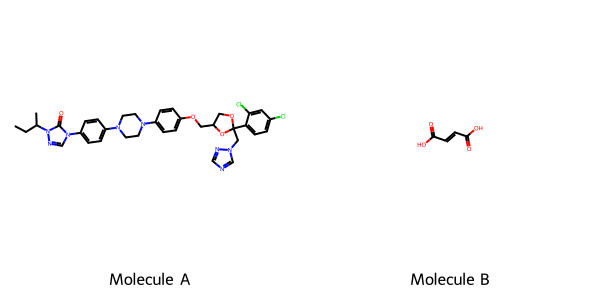

In [5]:
# Всегда перед началом работы стоит посмотреть на данные. Нарисуем пару молекул
def plot_molecule_pair(smiles1, smiles2, label):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    if mol1 and mol2:
        img = Draw.MolsToGridImage([mol1, mol2], molsPerRow=2,
                                   subImgSize=(300, 300),
                                   legends=["Molecule A", "Molecule B"])
        print(f"Label: {label} ({'Сокристалл образуется' if label==1 else 'Не образуется'})")
        display(img)
    else:
        print("Ошибка в SMILES строке")

# Визуализируем первую пару из датасета
sample_row = df.iloc[0]
plot_molecule_pair(sample_row['SMILES1'], sample_row['SMILES2'], sample_row['result'])

Можете менять индекс внутри .iloc чтобы рассмотреть другие пары, или, при желании, реализовать собственную функцию для продвинутого графического анализа молекул - это может натолкнуть на интересные идеи (не точно) и будет круто выглядеть на защите (100%)

##  1.4 Превращаем SMILES в Граф

Это самая важная часть. Мы должны перевести химию на язык цифр

PERMITTED_ATOM_TYPES - список атомов, которые мы распознаем. Остальные будут помечены как "Other"

В этом блоке оставлено очень много точек. Это сделано умышленно, чтобы вы смогли поэксперементировать не только с архитектурами и обучением, но и входными данными, и увидели, насколько изменения в их обработке могут сказаться на качестве всего пайплайна

In [6]:
PERMITTED_ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'Unknown']


def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return list(map(lambda s: x == s, allowable_set))

def get_atom_features(atom):
    """
    Собирает признаки атома.
    Мы не только рассматриваем структуру поатомно, но и учитываем химическое окружение.
    Вы можете улучшать эту часть, извлекая больше информации об атомах и связях между ними
    """
    # Тип атома
    # Элемент Unknown нужен для кодирования атомов, которых нет в списке PERMITTED_ATOM_TYPES
    results = one_hot_encoding(atom.GetSymbol(), PERMITTED_ATOM_TYPES)

    # Степень - количество соседей
    results += one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5, 'More'])

    # Явный заряд - важно для сокристаллов (соли vs кокристаллы)
    results += one_hot_encoding(atom.GetFormalCharge(), [-1, -2, 1, 2, 0]) # 0 в конце как дефолт

    # Гибридизация (плоская vs объемная молекула)
    results += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3])

    # Ароматичность - булевый флаг, важно для кристаллов
    results += [int(atom.GetIsAromatic())]

    # Точка роста:
    # Можно добавить сюда и другие характеристики для обогащения информации, на
    # которой вы учите сеть: IsInRing, Mass, Chirality, HydrogenBondDonor/Acceptor и т.д.

    return torch.tensor(results, dtype=torch.float)

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Узлы
    atom_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.stack(atom_features)

    # Ребра
    edge_indices = []

    # Точка роста: здесь мы учитываем только наличие связи, не ее тип (одинарная, двойная и т.д.)
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices.append([i, j])
        edge_indices.append([j, i])

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)

# Проверка размерности признаков - это важно учесть при проектировании архитектуры модели
test_dim = smiles_to_graph('C').x.shape[1]
print(f"Размерность вектора признаков одного атома: {test_dim}")

Размерность вектора признаков одного атома: 26


In [7]:
# Проверим работу функции на одной молекуле
test_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C" # Кофеин
graph = smiles_to_graph(test_smiles)

print("\n--- Пример графа (Кофеин) ---")
print(f"SMILES: {test_smiles}")
print(f"Количество атомов (nodes): {graph.num_nodes}")
print(f"Количество связей (edges): {graph.num_edges // 2}") # Делим на 2 так как связи двунаправленные
print(f"Размерность признаков узла (features): {graph.num_node_features}")
print("Структура объекта Data:", graph)


--- Пример графа (Кофеин) ---
SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
Количество атомов (nodes): 14
Количество связей (edges): 15
Размерность признаков узла (features): 26
Структура объекта Data: Data(x=[14, 26], edge_index=[2, 30])


# 2. PyTorch Geometric Dataset

In [8]:
class CocrystalDataset(Dataset):
    def __init__(self, dataframe):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
        # Датасет небольшой, семплы маленькие по объему информации, так что можно
        # сделать препроцессинг перед началом обучения, а не повторять его в процессе
        self.data_list = []

        for idx, row in tqdm(self.df.iterrows(), total=self.df.shape[0]):
            mol1 = smiles_to_graph(row['SMILES1'])
            mol2 = smiles_to_graph(row['SMILES2'])
            # Label делаем float для BCELoss
            label = torch.tensor([row['result']], dtype=torch.float)

            if mol1 is not None and mol2 is not None:
                # Возвращаем словарь. PyG сам превратит его в Batch-словарь
                self.data_list.append({
                    'mol1': mol1,
                    'mol2': mol2,
                    'label': label
                })

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

Сделаем простой split 80/20. В качестве улучшения можно менять размеры выборок, делать стратификацию, кросс-валидацию и т.д.

In [9]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CocrystalDataset(train_df)
val_dataset = CocrystalDataset(val_df)

  0%|          | 0/13062 [00:00<?, ?it/s]

  0%|          | 0/3266 [00:00<?, ?it/s]

In [10]:
batch_size = 32 # Можно эксперементировать с размером - влияет на стабильность и скорость сходимости

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 3. Архитектура

Пожалуй, одна из самых интересных и глобальных точек роста. Если решите не просто модифицировать представленную архитектуру Siamese GNN, а предложить свою - лучше начать с изучения актуальных статей по теме. Так вы не только сможете найти готовые реализации более современных подходов, но и посмотреть сравнения с другими распространенными моделями на разных датасетах. А если читать совсем внимательно, то даже рекомендации по обучению этих архитектур и подготовке данных, иногда это критично

In [11]:
class GNNEncoder(nn.Module):
    """
    Энкодер: превращает граф (x, edge_index) в embedding
    Используем простую GCN (Graph Convolutional Network)
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNNEncoder, self).__init__()
        # GCNConv - это свертка на графе. Она агрегирует информацию от соседей.
        # Точка роста: Заменить GCNConv на GATConv (Attention), GINEConv (с учетом
        # связей) или другие. Их можно последовательно комбинировать.
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        # Свертки
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training) # Регуляризация, помогает
        # предотвратить переобучение. Можете добавить и другие (weight_decay,
        # нормализация, ...). В данном случае, dropout в процессе обучения будет
        # занулять 10% (p=0.1) элементов вектора, получаемого на вход

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)

        # 2. Пулинг
        # Нам нужно из [Num_Atoms, Hidden_Dim] получить [1, Hidden_Dim] для всей молекулы.
        # global_mean_pool берет среднее по всем атомам молекулы.
        # Точка роста: Попробовать global_max_pool или global_add_pool (для суммирования масс/зарядов)
        x = global_mean_pool(x, batch)

        return x

In [12]:
class SiameseGNN(nn.Module):
    """
    Сиамская сеть: два входа, один энкодер, один классификатор.
    """
    def __init__(self, input_dim, hidden_dim=64, embedding_dim=32):
        super(SiameseGNN, self).__init__()

        # Единый энкодер для обеих молекул (веса общие)
        self.encoder = GNNEncoder(input_dim, hidden_dim, embedding_dim)

        # Классификатор, принимающий объединенные эмбеддинги
        # Вход: embedding_dim * 2, так как мы конкатенируем два вектора
        self.fc1 = nn.Linear(embedding_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1) # Выход: 1 число - вероятность

    def forward(self, mol1, mol2):
        # Получаем эмбеддинги для каждой молекулы
        # mol.x - признаки атомов
        # mol.edge_index - связи
        # mol.batch - вектор, указывающий, какому графу в батче принадлежит атом
        emb1 = self.encoder(mol1.x, mol1.edge_index, mol1.batch)
        emb2 = self.encoder(mol2.x, mol2.edge_index, mol2.batch)

        # Взаимодействие
        # Самый простой способ: склеить вектора - concatenation
        # Точка роста: попробовать другие способы объединения представлений молекул
        combined = torch.cat([emb1, emb2], dim=1)

        # Классификация
        x = self.fc1(combined)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.fc2(x)

        return torch.sigmoid(x)

# Инициализация модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = test_dim # Размерность, которую мы посчитали
model = SiameseGNN(input_dim=input_dim).to(device)

print(f"Модель инициализирована на {device}")
print(model)

Модель инициализирована на cpu
SiameseGNN(
  (encoder): GNNEncoder(
    (conv1): GCNConv(26, 64)
    (conv2): GCNConv(64, 64)
    (conv3): GCNConv(64, 32)
  )
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


# 4. Обучение и валидация

## 4.1 Настройка параметров обучения

Не стоит обделять вниманием эту часть пайлпайна: использование более продвинутого оптимизатора, class_weight, weight_decay и т.д. могут помочь модели сходиться лучше. Отслеживание большего числа метрик сделает контроль за обучением более наглядным, а вашу презентацию решения более весомой и информативной

In [13]:
def get_weighted_accuracy(y_true, y_pred_probs, threshold=0.5):
    """
    threshold - порог отсечения (как преобразовываем вероятность в бинарную метку)
    """
    y_true = np.array(y_true)
    y_pred_classes = (np.array(y_pred_probs) > threshold).astype(int)
    
    weights = np.where(y_true == 1, 0.1140, 0.8860)
    
    weighted_acc = np.sum(weights * (y_true == y_pred_classes)) / np.sum(weights)
    return weighted_acc

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss() # Binary Cross Entropy - стандарт для задач бинарной классификации
epochs = 15 # Небольшое количество эпох для демонстрации: смотрите на сходимость и меняйте
# колиество эпох, lr и другое
# Кроме того, можно добавить автоматическую остановку обучения, если, например,
# метрики на валидации не растут значительно последние n эпох

history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_wa': []}

# 3.2 Цикл обучения
for epoch in range(epochs):
    # Обучение
    model.train()
    train_loss = 0
    for batch in train_loader:
        # Перенос на рабочее устройство
        mol1 = batch['mol1'].to(device)
        mol2 = batch['mol2'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        # Forward pass
        out = model(mol1, mol2)

        # Loss
        loss = criterion(out, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Валидация
    model.eval() # Замораживаем веса перед валидацией!
    val_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in val_loader:
            mol1 = batch['mol1'].to(device)
            mol2 = batch['mol2'].to(device)
            labels = batch['label'].to(device)

            out = model(mol1, mol2)
            loss = criterion(out, labels)

            val_loss += loss.item()

            # Собираем метки для расчета ROC-AUC
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(out.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    # Рассчет метрик
    try:
        val_auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        val_auc = 0.5 # Если в батче только один класс

    val_wa = get_weighted_accuracy(y_true, y_pred) 
     
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_auc'].append(val_auc)
    history['val_wa'].append(val_wa)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val ROC-AUC: {val_auc:.4f} | "
          f"Val WA: {val_wa:.4f}")

Epoch 1/15 | Train Loss: 0.3608 | Val Loss: 0.2850 | Val ROC-AUC: 0.7551 | Val WA: 0.5336
Epoch 2/15 | Train Loss: 0.3025 | Val Loss: 0.2550 | Val ROC-AUC: 0.8333 | Val WA: 0.5797
Epoch 3/15 | Train Loss: 0.2803 | Val Loss: 0.2357 | Val ROC-AUC: 0.8636 | Val WA: 0.6089
Epoch 4/15 | Train Loss: 0.2641 | Val Loss: 0.2323 | Val ROC-AUC: 0.8770 | Val WA: 0.6194
Epoch 5/15 | Train Loss: 0.2578 | Val Loss: 0.2241 | Val ROC-AUC: 0.8815 | Val WA: 0.6687
Epoch 6/15 | Train Loss: 0.2478 | Val Loss: 0.2210 | Val ROC-AUC: 0.8886 | Val WA: 0.6240
Epoch 7/15 | Train Loss: 0.2404 | Val Loss: 0.2116 | Val ROC-AUC: 0.9003 | Val WA: 0.6297
Epoch 8/15 | Train Loss: 0.2331 | Val Loss: 0.2085 | Val ROC-AUC: 0.9043 | Val WA: 0.7076
Epoch 9/15 | Train Loss: 0.2250 | Val Loss: 0.2012 | Val ROC-AUC: 0.9112 | Val WA: 0.6772
Epoch 10/15 | Train Loss: 0.2165 | Val Loss: 0.1995 | Val ROC-AUC: 0.9133 | Val WA: 0.7390
Epoch 11/15 | Train Loss: 0.2096 | Val Loss: 0.1924 | Val ROC-AUC: 0.9202 | Val WA: 0.7366
Epoch 12

## 4.2 Визуализация обучения

На больших конкурсах, когда важно проводить и отслеживать много параллельных экспериментов, часто используют специальные готовые решения для визуализации (wandb, clearml и другие). Здесь это не обязательно, но разобраться с ними будет полезно и несложно, заодно у вас появятся красивые графики обучения для презентации

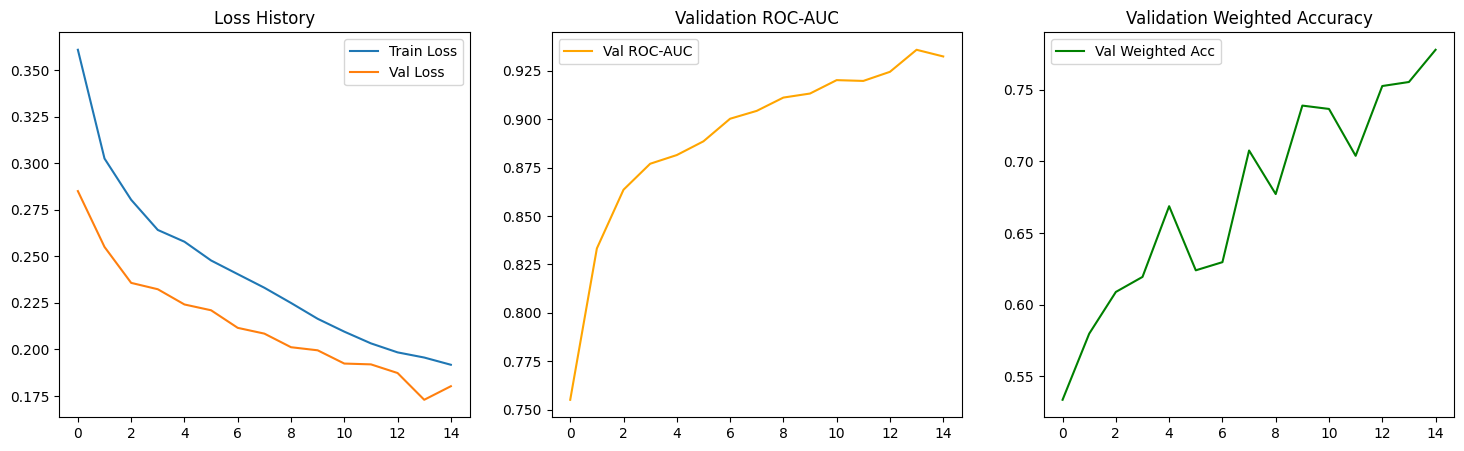

In [15]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['val_auc'], label='Val ROC-AUC', color='orange')
plt.title('Validation ROC-AUC')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['val_wa'], label='Val Weighted Acc', color='green')
plt.title('Validation Weighted Accuracy')
plt.legend()

plt.show()

# 5. Инференс и генерация сабмита

In [16]:
def predict_cocrystal(smiles1, smiles2, model, device):
    """
    Функция для использования модели.
    Принимает две строки SMILES, возвращает вероятность (0..1).
    """
    model.eval()

    # Превращаем строки в графы
    g1 = smiles_to_graph(smiles1)
    g2 = smiles_to_graph(smiles2)

    if g1 is None or g2 is None:
        return 0.0, "Invalid SMILES"

    # Создаем мини-батч из 1 элемента
    # Нам нужно добавить атрибут batch, так как модель его ожидает, иначе входной
    # сигнал не пройдет по размерности
    g1.batch = torch.zeros(g1.num_nodes, dtype=torch.long)
    g2.batch = torch.zeros(g2.num_nodes, dtype=torch.long)

    # Перенос на устройство
    g1 = g1.to(device)
    g2 = g2.to(device)

    # Прогон
    with torch.no_grad():
        prob = model(g1, g2)

    return prob.item()


Молекула A: O
Молекула B: CCCCCCCCCCCCCCCC
Вероятность: 0.9616
Label: 1 (Сокристалл образуется)


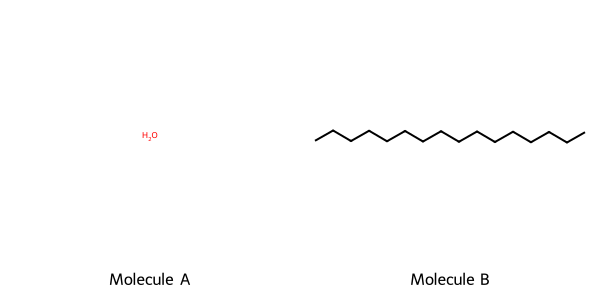

In [17]:
# Тут можно поэксперементировать со своими молекулами или взять из датасета
s1 = "O" # Вода
s2 = "CCCCCCCCCCCCCCCC" # Длинный алкан
prob = predict_cocrystal(s1, s2, model, device)

print(f"\nМолекула A: {s1}")
print(f"Молекула B: {s2}")
print(f"Вероятность: {prob:.4f}")

plot_molecule_pair(s1, s2, int(prob>0.5))

In [18]:
test_df = pd.read_csv('/kaggle/input/competitions/rascar-ai-chem-hack/test.csv')

submission_ids = []
submission_preds = []

# Обязательно переводим модель в режим оценки - отключит Dropout, повлияет на BatchNorm
model.eval()

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    smiles1 = row['SMILES1']
    smiles2 = row['SMILES2']
    pair_id = row['id']
    
    prob = predict_cocrystal(smiles1, smiles2, model, device)
    if isinstance(prob, tuple): 
        prob = prob[0] # Защита, если молекула битая
            
    # Задаем threashold перевода
    pred_class = 1 if prob > 0.5 else 0
        
    submission_ids.append(pair_id)
    submission_preds.append(pred_class)

submission_df = pd.DataFrame({
    'id': submission_ids,
    'result': submission_preds
})

# index=False обязателен, чтобы система съела ваш сабмишн
submission_df.to_csv('submission.csv', index=False)
display(submission_df.head())

  0%|          | 0/1000 [00:00<?, ?it/s]

,id,result
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


Надеюсь, бейзлайн окажется понятным и полезным, можете оценить его апвоутом :)